<h1 align="center"><b>Лабораторна робота №3</b></h1>
<h3 align="right">Роботу виконав <br>студент групи ФІ-21, <br>Беркута Володимир</h3>

### Завдання №1
Аналіз чутливості параметрів стохастичних моделей

**Мета**

Поглибити розуміння відміностей між детермінованими та стохастичними моделями, а також дослідити, як невизначеність впливає на поведінку систем.


In [1]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

plt.style.use('ggplot')

#### Природничі процеси(Популяційний ріст)

Провести аналіз чутливості, змінюючи параметри $r, K$ та $\sigma$, і побудувати графіки для обох підходів. Проаналізувати, як зміни цих параметрів впливає на траєкторію популяції.

Класична логістична модель має вигляд

$$
\frac{dy(t)}{dt} = ry(t) \left( 1 - \frac{y(t)}{K} \right),
$$
де
* $y(t)$ — численість популяції в час $t$,
* $r$ — швидкість зростання,
* $K$ — місткість середовища.

Щоб врахувати природні флуктуації (наприклад, сезонність, випадкові зміни умов середовища), додаємо стохастичний член:

$$
dy(t) = ry(t) \left( 1 - \frac{y(t)}{K} \right)dt + \sigma y(t) dW(t),
$$
де
* $\sigma$ — інтенсивність шуму,
* $dW(t)$ — приріст стандартного Вінерівського процесу, який за кожним кроком часу $\Delta t$ є нормально розподіленим зі середнім $0$ та дисперсією $\Delta t$.

Оскільки рівняння містить стохастичний член, класичний метод Ейлера для чисельного інтегрування диференціальних рівнянь не враховує особливості інтегрування випадкових величин. Для розв'язання стохастичних диференціальних рівнянь (СДР) застосовується метод Ейлера-Марйами, який має форму:

$$
y_{n+1} = y_n + f(y_n)\Delta t + g(y_n)\Delta W_n,
$$

де
* $f(y) = ry \left( 1 - \frac{y}{K} \right)$ — детермінована частина,
* $g(y) = \sigma y$ — стохастичний коефіцієнт,
* $\Delta W_n \sim N(0, \Delta t)$ — приріст Вінерівського процесу на кроці $\Delta t$.

Таким чином, метод Ейлера-Маруйами є логічним вибором для інтегрування нашої стохастичної логістичної моделі, оскільки він коректно апроксимує як детерміновану, так і стохастичну частини рівння.

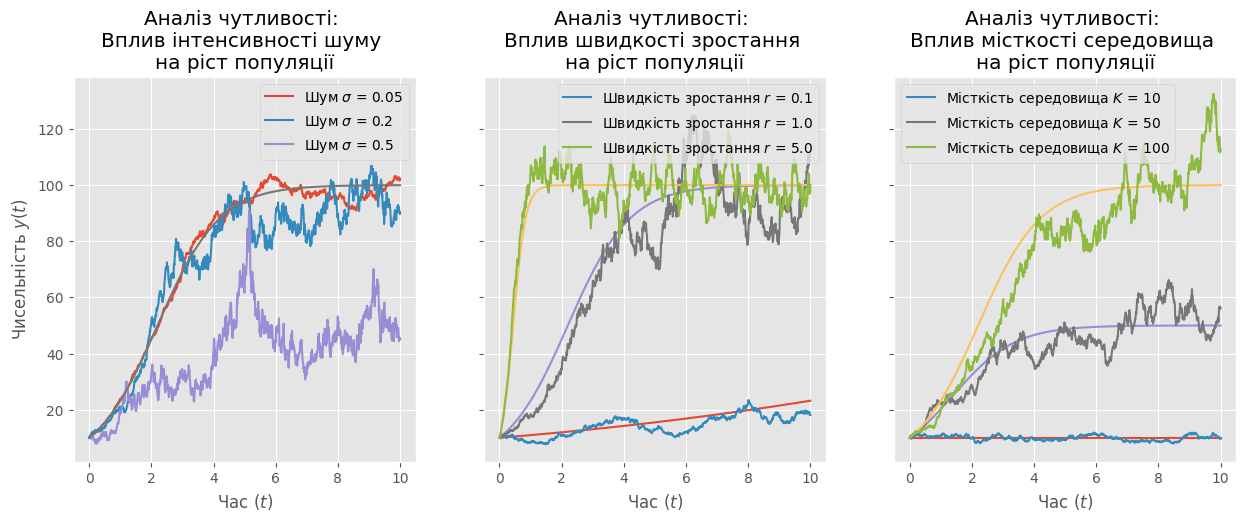

<Figure size 1200x600 with 0 Axes>

In [2]:
# Параметри моделі
r, K, y0, T, n_steps = 1.0, 100.0, 10.0, 10, 1000
dt = T / n_steps
t = np.linspace(0, T, n_steps)

fig, axs = plt.subplots(ncols=3, figsize=(15, 5), sharey=True)

# Різні рівні шуму (сигма)
sigmas = [0.05, 0.2, 0.5]
plt.figure(figsize=(12, 6))

for sigma in sigmas:
    y_stoch = np.zeros(n_steps)
    y_stoch[0] = y0
    for i in range(1, n_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        y_stoch[i] = y_stoch[i-1] + r * y_stoch[i-1] * (1 - y_stoch[i-1] / K) * dt + sigma * y_stoch[i-1] * dW
    axs[0].plot(t, y_stoch, label=rf"Шум $\sigma$ = {sigma}")

solution = K / (1 + ((K - y0) / y0) * np.exp(-r * t))
axs[0].plot(t, solution)
axs[0].set_title("Аналіз чутливості: \nВплив інтенсивності шуму \nна ріст популяції")
axs[0].set_xlabel(r"Час $(t)$")
axs[0].set_ylabel(r"Чисельність $y(t)$")
axs[0].legend()
axs[0].grid(True)

r_s = np.array([.1, 1, 5])
sigma = .2

for r in r_s:
    y_stoch = np.zeros(n_steps)
    y_stoch[0] = y0
    for i in range(1, n_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        y_stoch[i] = y_stoch[i-1] + r * y_stoch[i-1] * (1 - y_stoch[i-1] / K) * dt + sigma * y_stoch[i-1] * dW
    
    solution = K / (1 + ((K - y0) / y0) * np.exp(-r * t))
    axs[1].plot(t, solution)
    axs[1].plot(t, y_stoch, label=rf"Швидкість зростання $r$ = {r}")

axs[1].set_title("Аналіз чутливості: \nВплив швидкості зростання \nна ріст популяції")
axs[1].set_xlabel(r"Час $(t)$")
axs[1].legend()
axs[1].grid(True)

K_s = np.array([10, 50, 100])
sigma = .2
r = 1

for K in K_s:
    y_stoch = np.zeros(n_steps)
    y_stoch[0] = y0
    for i in range(1, n_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        y_stoch[i] = y_stoch[i-1] + r * y_stoch[i-1] * (1 - y_stoch[i-1] / K) * dt + sigma * y_stoch[i-1] * dW
    solution = K / (1 + ((K - y0) / y0) * np.exp(-r * t))
    axs[2].plot(t, solution)
    axs[2].plot(t, y_stoch, label=rf"Місткість середовища $K$ = {K}")

axs[2].set_title("Аналіз чутливості: \nВплив місткості середовища \nна ріст популяції")
axs[2].set_xlabel(r"Час $(t)$")
axs[2].legend()
axs[2].grid(True)

#### Економічні процеси (Модель економічного замовлення, EOQ)
Порівняти оптимальні значення $Q$ для детермінованої та стохастичної моделі та проаналізувати вплив невизначеності попиту.

Класична модель економічного замовлення (EOQ) для постійного попиту має вигляд:

$$
TC(Q) = \frac{D}{Q}S + \frac{Q}{2}H,
$$
де
* $D$ — щорічний попит (одиниць продукції),
* $S$ — вартість оформлення одного замовлення,
* $H$ — вартість зберігання одиниці товару за рік,
* $Q$ — розмір замовлення.

У стохастичній модифікації попит $D$ є випадковою величиною. Припустимо, що попит має нормальний розподіл:
$$
D \sim N(\mu_D, \sigma_D),
$$
де $\mu_D$ — середній попит, $\sigma_D$ — стандартне відхилення попиту.
Оскільки $D$ є випадковою, загальні витрати також стають випадковими ведичинами:

$$
TC(Q) = \frac{D}{Q}S + \frac{Q}{2}H.
$$
За допомогою симуляцій методом Монте-Карло можна оцінити очікувані загальні витрати для кожного значення $Q$, проводячи численні симцляції попиту.

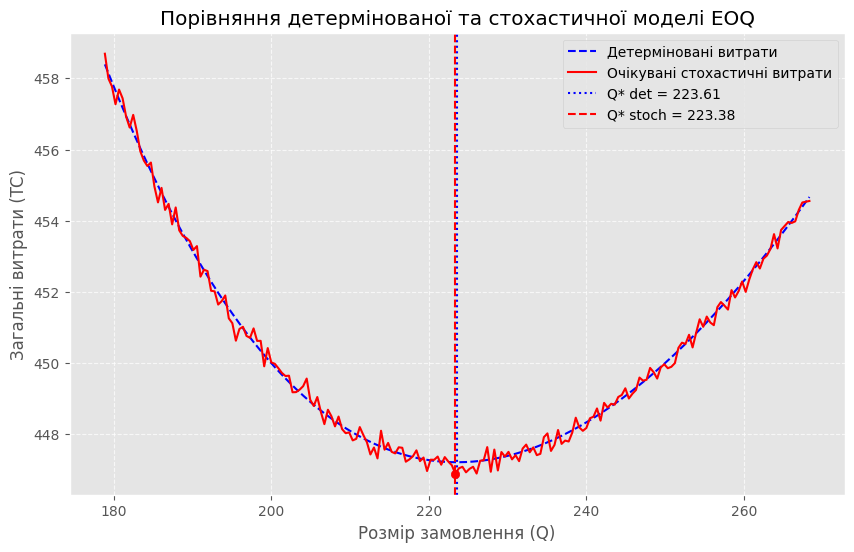

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Параметри
mu_D, S, H = 1000.0, 50.0, 2.0
sigma_D = 200.0
n_sim = 50000

# Оптимальне Q для детермінованої моделі
Q_opt_det = np.sqrt((2 * mu_D * S) / H)
Q_values = np.linspace(Q_opt_det * 0.8, Q_opt_det * 1.2, 200)

TC_det = (mu_D / Q_values) * S + (Q_values / 2) * H
TC_stoch_mean = []

# Симуляція
for Q in Q_values:
    D_samples = np.maximum(np.random.normal(mu_D, sigma_D, n_sim), 0)
    TC_samples = (D_samples / Q) * S + (Q / 2) * H
    TC_stoch_mean.append(np.mean(TC_samples))

# Пошук стохастичного оптимуму
idx_min = np.argmin(TC_stoch_mean)
Q_opt_stoch = Q_values[idx_min]
min_cost_stoch = TC_stoch_mean[idx_min]

plt.figure(figsize=(10, 6))
plt.plot(Q_values, TC_det, 'b--', label="Детерміновані витрати")
plt.plot(Q_values, TC_stoch_mean, 'r-', label="Очікувані стохастичні витрати")

# Позначення обох оптимумів
plt.axvline(Q_opt_det, color='blue', linestyle=':', label=f"Q* det = {Q_opt_det:.2f}")
plt.axvline(Q_opt_stoch, color='red', linestyle='--', label=f"Q* stoch = {Q_opt_stoch:.2f}")
plt.scatter(Q_opt_stoch, min_cost_stoch, color='red', zorder=5)

plt.title("Порівняння детермінованої та стохастичної моделі EOQ")
plt.xlabel("Розмір замовлення (Q)")
plt.ylabel("Загальні витрати (TC)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Соціальні процеси (Модель соціальної динаміки)

Проаналізувати, як початкове значення $x_0$ та критичний поріг $\theta$ випливають на кінцеву поведінку системи. Побудувати графіки для детерміністичного та стохастичного рішень і сформулювати висновки щодо стабільності рівноважних станів.

Нехай $x(t)$ — частка населення, що підтримує певну ідею або соцілальну поведінку. У детермінованій моделі маємо рівняння:

$$
\frac{dx}{dt} = kx(t) (1 - x(t))(x(t) - \theta),
$$
де
* $k > 0$ — коефіцієнт швидкості динаміки,
* $\theta$ — критичний поріг, що розділяє зони поширення ідеї.

Для врахуваня впливу випадкових зовнішніх факторів додаємо адитивний шум:

$$
dx = kx (1 - x)(x - \theta)dt + \sigma dW(t),
$$
де $\sigma$ — інтенсивність зовнішніх флуктуацій, а $dW(t)$ — приріст Вінерівського процесу.

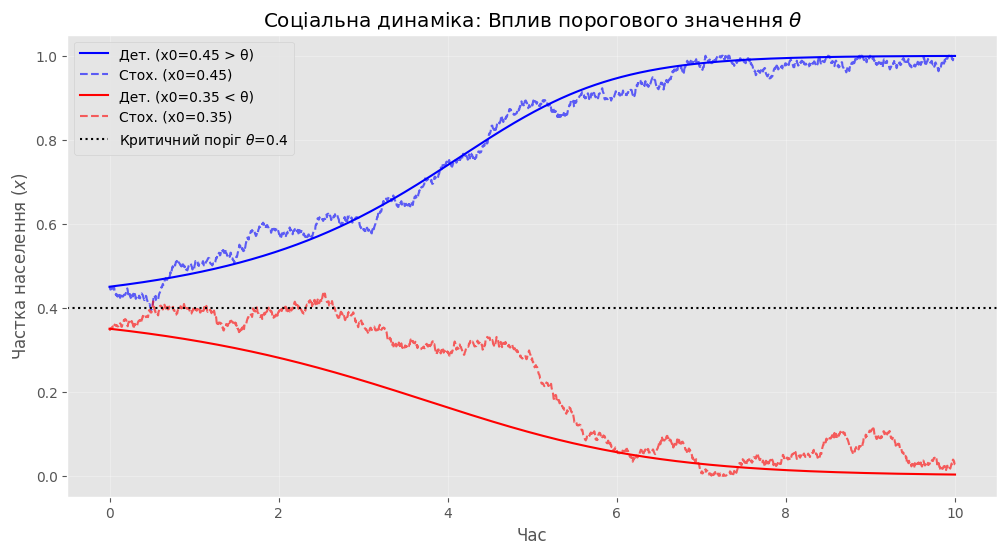

In [4]:
def simulate_social_dynamics(x0, theta, k, sigma, T, n_steps):
    dt = T / n_steps
    t = np.linspace(0, T, n_steps)
    
    # Детерміноване рішення (без шуму)
    x_det = np.zeros(n_steps)
    x_det[0] = x0
    for i in range(1, n_steps):
        # k * x * (1 - x) * (x - theta)
        dx = k * x_det[i-1] * (1 - x_det[i-1]) * (x_det[i-1] - theta) * dt
        x_det[i] = np.clip(x_det[i-1] + dx, 0, 1)
        
    # Стохастичне рішення
    x_stoch = np.zeros(n_steps)
    x_stoch[0] = x0
    for i in range(1, n_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        drift = k * x_stoch[i-1] * (1 - x_stoch[i-1]) * (x_stoch[i-1] - theta) * dt
        diffusion = sigma * dW
        x_stoch[i] = np.clip(x_stoch[i-1] + drift + diffusion, 0, 1)
        
    return t, x_det, x_stoch

# Параметри
k = 2.0
theta = 0.4
sigma = 0.05
T = 10
n_steps = 2000

# Моделювання для двох різних початкових значень
t, x_det_high, x_stoch_high = simulate_social_dynamics(0.45, theta, k, sigma, T, n_steps)
_, x_det_low, x_stoch_low = simulate_social_dynamics(0.35, theta, k, sigma, T, n_steps)

# Візуалізація
plt.figure(figsize=(12, 6))
plt.plot(t, x_det_high, 'b-', label=f'Дет. (x0=0.45 > θ)')
plt.plot(t, x_stoch_high, 'b--', alpha=0.6, label='Стох. (x0=0.45)')
plt.plot(t, x_det_low, 'r-', label=f'Дет. (x0=0.35 < θ)')
plt.plot(t, x_stoch_low, 'r--', alpha=0.6, label='Стох. (x0=0.35)')
plt.axhline(theta, color='black', linestyle=':', label=rf'Критичний поріг $\theta$={theta}')

plt.title(r"Соціальна динаміка: Вплив порогового значення $\theta$")
plt.xlabel("Час")
plt.ylabel(r"Частка населення $(x)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Завдання №2
Побудова та аналіз портфеля активів

**Мета**

Застосувати метод Монте-Карло для оцінки портфельної доходності, аналізу ризику та прийняття рішень щодо ребалансування портфеля.

1) Збір та обробка даних:
    * Використовуючи бібліотеку `yfinance` або синтетичні дані, зберіть історичні дані для трьох активів (наприклад, TSLA, GOOG, GM).
    * Розрахувати історичну річну дохідність та волатильність для кожного активу.
    * Задати ваги активів у портфелі так, щоб
    $$
        \sum_{i=1}^{3}w_i = 1.
    $$
2) Симуляція портфельної дохідності:
    * Припустити, що дохідність активів мають нормальний розподіл з параметрами, визначеними на попередньому кроці.
    * Розразувати портфельну дохідність для кожної симуляції за формулою
    $$
        R_p = w_1 r_1 + w_2 r_2 + w_3 r_3. 
    $$
    * Обчислити такі показники:
        * Очікувана дохідність портфеля,
        * Ризик портфеля (стандартне відхилення),
        * Value-at-Risk (VaR) на рівні $5\%$.
3) Віалізація та аналіз
    * Побудувати гістограму розподілу портфельнох дохідності з вертикальними лініями, позначають середнє значення та VaR ($5\%$).
    * Сформулювати рекомендації щодо ребалансування портфеля: чи потрібно змінити ваги активів або додати нові активи, щоб оптимізувати співвідношення дохідності та ризику.

In [5]:
# Збір та обробка реальних даних
assets = ['TSLA', 'GOOG', 'GM']
start_date = '2020-01-01'
end_date = '2025-01-01'

print(f"Завантаження даних для {assets}...")
data = yf.download(assets, start=start_date, end=end_date)['Close']

Завантаження даних для ['TSLA', 'GOOG', 'GM']...


[*********************100%***********************]  3 of 3 completed


In [6]:
# Розрахунок щоденних доходностей
daily_returns = data.pct_change().dropna()

# Розрахунок історичної річної дохідності та волатильності
# (252 — середня кількість торгових днів у році)
annual_returns = daily_returns.mean() * 252
annual_volatility = daily_returns.std() * np.sqrt(252)

for asset in assets:
    print(f"{asset}: Доходність = {annual_returns[asset]:.2%}, Волатильність = {annual_volatility[asset]:.2%}")

TSLA: Доходність = 75.53%, Волатильність = 67.18%
GOOG: Доходність = 25.86%, Волатильність = 32.38%
GM: Доходність = 17.16%, Волатильність = 43.14%


In [7]:
# Задаємо ваги портфеля (сума = 1)
weights = np.array([.3, .4, .3])
# 2. Симуляція Монте-Карло
n_simulations = 1_000_000
sim_returns = np.random.normal(annual_returns, annual_volatility, (n_simulations, len(assets)))

In [8]:
# Розрахунок доходності портфеля для кожної симуляції
# Rp = w1*r1 + w2*r2 + w3*r3
portfolio_sim_returns = np.dot(sim_returns, weights)

# Обчислення ключових показників
expected_return = np.mean(portfolio_sim_returns)
portfolio_risk = np.std(portfolio_sim_returns)
var_5 = np.percentile(portfolio_sim_returns, 5)

Результати симуляції портфеля
Очікувана доходність: 38.14%
Ризик портфеля (Std Dev): 27.25%
Value-at-Risk (VaR 5%): -6.73%


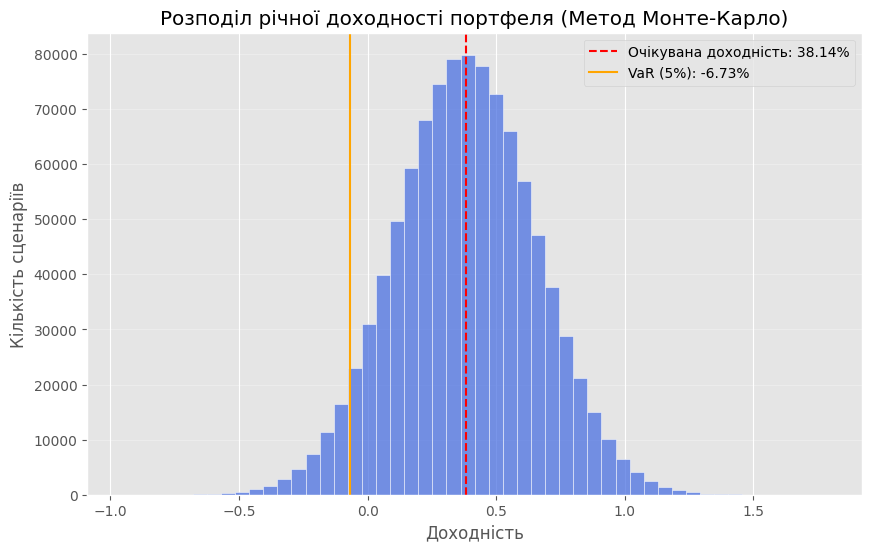

In [9]:
print("Результати симуляції портфеля")
print(f"Очікувана доходність: {expected_return:.2%}")
print(f"Ризик портфеля (Std Dev): {portfolio_risk:.2%}")
print(f"Value-at-Risk (VaR 5%): {var_5:.2%}")

# 3. Візуалізація
plt.figure(figsize=(10, 6))
plt.hist(portfolio_sim_returns, bins=50, color='royalblue', alpha=0.7, edgecolor='white')

# Додаємо лінії показників
plt.axvline(expected_return, color='red', linestyle='--', label=f'Очікувана доходність: {expected_return:.2%}')
plt.axvline(var_5, color='orange', linestyle='-', label=f'VaR (5%): {var_5:.2%}')

plt.title('Розподіл річної доходності портфеля (Метод Монте-Карло)')
plt.xlabel('Доходність')
plt.ylabel('Кількість сценаріїв')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Додаткове завдання
Дати відповіді на наступні запитання:
* Які обмеження має метод Монте-Карло для оцінки портфельної дохідності?

    * Точність моделювання критично залежить від якості оцінки очікуваної дохідності та волатильності. Помилкові історичні дані призводять до невірних симуляцій. 
    * Метод часто передбачає, що зв'язки між активами залишаються постійними. Проте під час фінансових криз кореляції зазвичай різко зростають, і активи, які мали диверсифікувати ризик, падають одночасно.
    * Для отримання стат значущих результатів необхідно проводити сотні тисяч ітерацій, що вимагає значних ресурсів.
    * Симуляція припускає можливість продати актив за ціною моделі, не враховуючи реальні ринкові труднощі під час паніки.

* Які інші методи можна використовувати для аналізу та упрвління портфелем?

    * Модель Марковіца (Mean-Variance Optimization), мат спосіб "ефективної межі" набору портфелів, що забезпечують мінімальний ризик для заданого рівня дохідності.
    * Модель Блека-Літтермана, поєднує ринкову рівновагу з суб’єктивними прогнозами інвестора, що дозволяє уникнути надмірної концентрації активів в одній позиції.
    * Сценарний аналіз, моделювання поведінки портфеля за конкретних історичних або гіпотетичних умов.
    * Факторні моделів (CAPM), оцінка дохідності на основі чутливості активу до загальних ринкових чинників.

* Чи можна використовувати інші розподіли ймовірностей для моделювання дохідностей активів, крім нормального? Які аргументи за та проти?

    * Так, оскільки: 
        * реальні ринкові дані часто мають товсті хвости. Це означає, що екстремальні події стаються частіше, ніж передбачає нормальний розподів
    
    * Ні, бо
        * Розрахунки стають складнішими, а параметри важче точно оцінити на обмежених даних.
        * Моделювання складних розподілів у методі Монте-Карло потребує більше часу та потужностей.

* Як врахувати невизначеність щодо майбутніх дохідностей активів?

    * Аналіз чутливості, перевірка того, як зміна очікуваної дохідності або волатильності одного активу на кілька відсотків впливає на кінцевий результат усього портфеля.
    * Баєсівський підхід, постійне оновлення ймовірностей дохідності при отриманні нових ринкових даних.
    * Метод Бустреп, випадковий вибір реальних історичних значень замість генераціх чисел за формулою. Це дозволяє зберегти всі "дивацтва" реального ринку всередині моделі.
    * Інтервальні пронози, використання діапазонів значень замість одного точкового прогнозу.

* Які існують альтернативні методи оцінки ризику, крім VaR?

    * Expected Shortfall (CVaR\Умовний VaR)
    * Коефіцієнт Шарпа
    * Максимальна просадка (Maximum Drawdown)
    * Коефіцієнт Сортіно

### *Додаткове завдання
Аналіз часових рядів для прогнозування економічних показників

**Мета**
Застосувати SARIMA та ARIMA моделі для аналізу часових рядів та здійснення короткострокового прогнозу.

**Завдання**
1) Підготовка даних
    * Сформувати часовий ряд із $n$ спостережень (наприклад, $n = 2000$) за допмогою синтетичних або реальних економічних даних (наприклад, індекс чи обсяги продажів).
2) Фітинг моделей
    * Застосувати ARIMA-модель до отриманих даних.
    * Застосувати SARIMA-модель до отриманих даних.
    * Виконати фітинг моделі та зробити прогноз на наступні $T$ періодів (наприклад, $T=20$).
3) Візуалізація
    * Побудувати графік, що показує історичні дані та прогнозовані значення.
4) Аналіз
    * Описати виявлені тренди, сезонність і автокореляцію.
    * Пояснити, як отриманий прогноз моде допомогти у прийнятті управлінських рішень (наприклад, у бюджетуванні чи плануванні виробництва).
    * Пояснити відмінність між моделями та актуальність їх застосування для різних даних та задач.

In [10]:
np.random.seed(42)
n = 2000
t = np.arange(n)

# Компоненти: Тренд + Сезонність (7 днів) + Шум
trend = 0.05 * t
seasonality = 10 * np.sin(2 * np.pi * t / 7)
noise = np.random.normal(0, 5, n)
data = 100 + trend + seasonality + noise

ts = pd.Series(data)

In [11]:
# Фітинг моделей
# ARIMA (p=5, d=1, q=0) - враховуємо авторегресію та тренд
arima_model = ARIMA(ts, order=(5, 1, 0))
arima_result = arima_model.fit()

# SARIMA (p=1, d=1, q=1) x (P=1, D=1, Q=1, s=7) - додаємо сезонний цикл 7 днів
sarima_model = SARIMAX(ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_result = sarima_model.fit(disp=False)

# Прогноз на T=20 періодів
T = 20
arima_forecast = arima_result.get_forecast(steps=T).predicted_mean
sarima_forecast = sarima_result.get_forecast(steps=T).predicted_mean

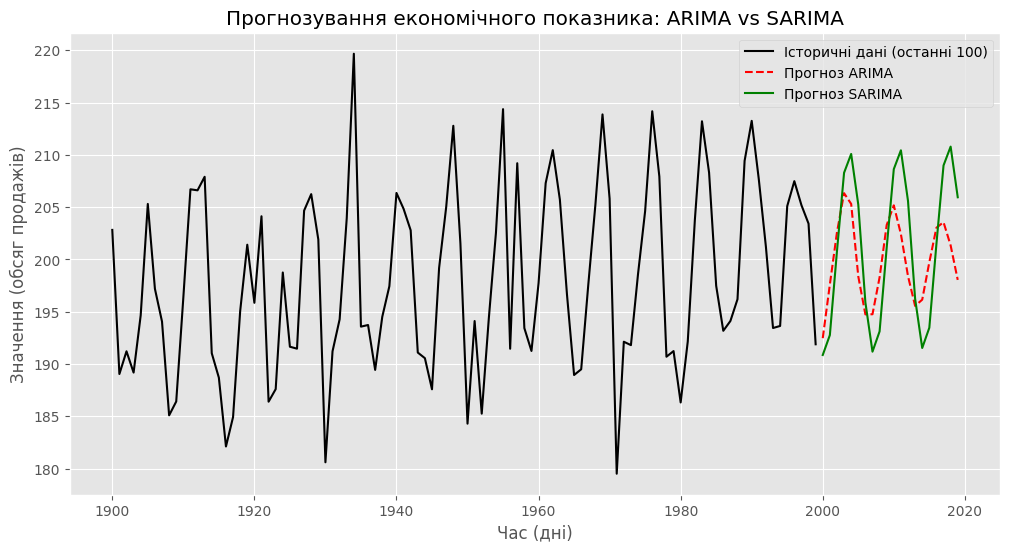

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(ts.iloc[-100:], label='Історичні дані (останні 100)', color='black')
plt.plot(np.arange(n, n + T), arima_forecast, label='Прогноз ARIMA', color='red', linestyle='--')
plt.plot(np.arange(n, n + T), sarima_forecast, label='Прогноз SARIMA', color='green', linestyle='-')

plt.title('Прогнозування економічного показника: ARIMA vs SARIMA')
plt.xlabel('Час (дні)')
plt.ylabel('Значення (обсяг продажів)')
plt.legend()
plt.show()